In [1]:
!pip install requests beautifulsoup4 pandas lxml

In [4]:
import requests
import pandas as pd

url = "https://en.wikipedia.org/wiki/List_of_countries_by_rice_production"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)

tables = pd.read_html(response.text)

print(len(tables))

11


/tmp/ipython-input-3909544603.py:12: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


In [5]:
tables[0].head()

,Rank,Country/region,Rice production (tonnes)
0,">1,000,000 tonnes",">1,000,000 tonnes",">1,000,000 tonnes"
1,1,India,265098885
2,2,China,255245235
3,3,Bangladesh,57189193
4,4,Indonesia,54748977


In [6]:
df = tables[0]
df.head()

,Rank,Country/region,Rice production (tonnes)
0,">1,000,000 tonnes",">1,000,000 tonnes",">1,000,000 tonnes"
1,1,India,265098885
2,2,China,255245235
3,3,Bangladesh,57189193
4,4,Indonesia,54748977


In [7]:
df.to_csv("rice_production.csv", index=False)

In [8]:
from google.colab import files
files.download("rice_production.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122 entries, 0 to 121
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Rank                      122 non-null    object
 1   Country/region            122 non-null    object
 2   Rice production (tonnes)  122 non-null    object
dtypes: object(3)
memory usage: 3.0+ KB


In [11]:
df = df.iloc[1:]   # removes first row
df.head()

,Rank,Country/region,Rice production (tonnes)
1,1,India,265098885
2,2,China,255245235
3,3,Bangladesh,57189193
4,4,Indonesia,54748977
5,5,Vietnam,42672339


In [13]:
df["Rice production (tonnes)"] = (
    df["Rice production (tonnes)"]
    .str.replace(",", "", regex=True)   # remove commas
    .str.replace(" ", "", regex=True)   # remove spaces
)

df["Rice production (tonnes)"] = pd.to_numeric(
    df["Rice production (tonnes)"],
    errors="coerce"
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 1 to 121
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Rank                      121 non-null    object 
 1   Country/region            121 non-null    object 
 2   Rice production (tonnes)  117 non-null    float64
dtypes: float64(1), object(2)
memory usage: 3.0+ KB


/tmp/ipython-input-2790577625.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Rice production (tonnes)"] = (
/tmp/ipython-input-2790577625.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Rice production (tonnes)"] = pd.to_numeric(


In [14]:
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 117 entries, 1 to 121
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Rank                      117 non-null    object 
 1   Country/region            117 non-null    object 
 2   Rice production (tonnes)  117 non-null    float64
dtypes: float64(1), object(2)
memory usage: 3.7+ KB


In [15]:
df["Rank"] = pd.to_numeric(df["Rank"])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 117 entries, 1 to 121
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Rank                      117 non-null    int64  
 1   Country/region            117 non-null    object 
 2   Rice production (tonnes)  117 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 3.7+ KB


In [16]:
X = df[["Rank"]]   # Input
y = df["Rice production (tonnes)"]   # Output

print(X.head())
print(y.head())

   Rank
1     1
2     2
3     3
4     4
5     5
1    265098885.0
2    255245235.0
3     57189193.0
4     54748977.0
5     42672339.0
Name: Rice production (tonnes), dtype: float64


In [17]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

print("Model trained successfully")

Model trained successfully


In [18]:
y_pred = model.predict(X)

print(y_pred[:5])

[28374858.51848473 28017093.50675429 27659328.49502386 27301563.48329343
 26943798.471563  ]


In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 13545954.418387355
RMSE: 32375034.184683897


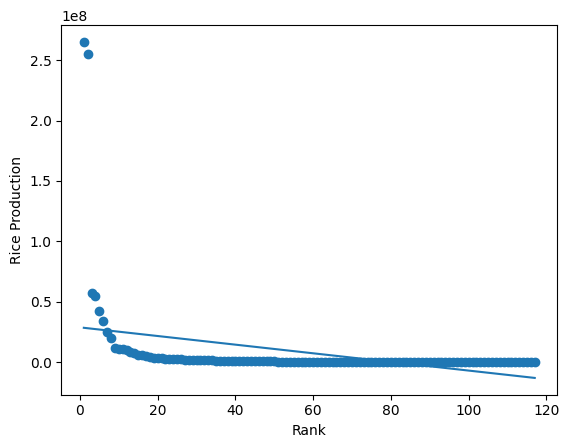

In [20]:
import matplotlib.pyplot as plt

plt.scatter(X, y)
plt.plot(X, y_pred)
plt.xlabel("Rank")
plt.ylabel("Rice Production")
plt.show()

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 13545954.418387355
RMSE: 32375034.184683897


In [22]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 26.1 MB/s eta 0:00:00


In [23]:
import optuna
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
import numpy as np

def objective(trial):

    alpha = trial.suggest_float("alpha", 0.0001, 10.0)

    model = Ridge(alpha=alpha)
    model.fit(X, y)

    preds = model.predict(X)

    rmse = np.sqrt(mean_squared_error(y, preds))

    return rmse

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20)

print("Best Parameters:", study.best_params)
print("Best RMSE:", study.best_value)

[I 2026-02-22 06:37:57,803] A new study created in memory with name: no-name-3cd6aebd-d29e-4a37-b5c3-70bfce6e26da
[I 2026-02-22 06:37:57,834] Trial 0 finished with value: 32375034.184856534 and parameters: {'alpha': 1.167777622195958}. Best is trial 0 with value: 32375034.184856534.
[I 2026-02-22 06:37:57,854] Trial 1 finished with value: 32375034.185077034 and parameters: {'alpha': 1.7622505630809482}. Best is trial 0 with value: 32375034.184856534.
[I 2026-02-22 06:37:57,873] Trial 2 finished with value: 32375034.188831955 and parameters: {'alpha': 5.724383075787578}. Best is trial 0 with value: 32375034.184856534.
[I 2026-02-22 06:37:57,892] Trial 3 finished with value: 32375034.185902808 and parameters: {'alpha': 3.1030126761372205}. Best is trial 0 with value: 32375034.184856534.
[I 2026-02-22 06:37:57,905] Trial 4 finished with value: 32375034.18516853 and parameters: {'alpha': 1.956597917112799}. Best is trial 0 with value: 32375034.184856534.
[I 2026-02-22 06:37:57,916] Trial 5

Best Parameters: {'alpha': 0.017239224138984197}
Best RMSE: 32375034.18468393


In [24]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 101.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 84.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 54.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 808.4/808.4 kB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 18.6 MB/s eta 0:00:00


In [25]:
import mlflow
import mlflow.sklearn
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
import numpy as np

mlflow.set_experiment("Rice Production Experiment")

with mlflow.start_run():

    model = Ridge(alpha=0.017239224138984197)
    model.fit(X, y)

    preds = model.predict(X)

    rmse = np.sqrt(mean_squared_error(y, preds))

    mlflow.log_param("alpha", 0.017239224138984197)
    mlflow.log_metric("rmse", rmse)

    mlflow.sklearn.log_model(model, "ridge-model")

    print("Run logged in MLflow")

2026/02/22 06:39:34 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/02/22 06:39:34 INFO mlflow.store.db.utils: Updating database tables
2026/02/22 06:39:37 INFO mlflow.tracking.fluent: Experiment with name 'Rice Production Experiment' does not exist. Creating a new experiment.
2026/02/22 06:39:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/22 06:39:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run logged in MLflow


In [28]:
!ls mlruns

1


In [29]:
import pickle

with open("rice_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved successfully")

Model saved successfully


In [31]:
from google.colab import files
files.download("rice_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
!pip install fastapi uvicorn nest-asyncio pyngrok

In [33]:
%%writefile app.py

import pickle
from fastapi import FastAPI

app = FastAPI()

# Load model
with open("rice_model.pkl", "rb") as f:
    model = pickle.load(f)

@app.get("/")
def home():
    return {"message": "Rice Production Prediction API"}

@app.get("/predict")
def predict(rank: float):

    prediction = model.predict([[rank]])

    return {"rank": rank, "predicted_production": float(prediction[0])}

Writing app.py


In [35]:
from app import app

In [39]:
import nest_asyncio
nest_asyncio.apply()

from app import app
import uvicorn
import threading

def run_server():
    uvicorn.run(app, host="0.0.0.0", port=8000)

thread = threading.Thread(target=run_server)
thread.start()

print("Server started successfully")

/usr/lib/python3.12/contextlib.py:272: RuntimeWarning: coroutine 'Server.serve' was never awaited
  def contextmanager(func):


Server started successfully


In [60]:
import nest_asyncio
nest_asyncio.apply()

from app import app
import uvicorn
import threading

def run_server():
    uvicorn.run(app, host="127.0.0.1", port=8000)

thread = threading.Thread(target=run_server)
thread.start()

print("✅ FastAPI server started")

✅ FastAPI server started


INFO:     Started server process [1827]


In [61]:
import requests

url = "http://127.0.0.1:8000/predict?rank=10"

response = requests.get(url)

print(response.json())

INFO:     127.0.0.1:38844 - "GET /predict?rank=10 HTTP/1.1" 200 OK
{'rank': 10.0, 'predicted_production': 25154971.14843863}


/usr/lib/python3.12/importlib/__init__.py:90: RuntimeWarning: coroutine 'Server.serve' was never awaited
  return _bootstrap._gcd_import(name[level:], package, level)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(


In [62]:
import numpy as np

# Training data statistics
train_mean = y.mean()

def monitor_input(new_rank):

    prediction = model.predict([[new_rank]])[0]

    deviation = abs(prediction - train_mean)

    if deviation > train_mean * 0.5:
        status = "⚠ Drift Detected"
    else:
        status = "✅ Normal Input"

    return {
        "rank": new_rank,
        "prediction": float(prediction),
        "status": status
    }

monitor_input(10)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(


{'rank': 10, 'prediction': 25154971.14843863, 'status': '⚠ Drift Detected'}

In [63]:
from sklearn.linear_model import Ridge

def retrain_if_needed(rank):

    result = monitor_input(rank)

    if "Drift" in result["status"]:

        print("⚠ Drift detected → Retraining model...")

        new_model = Ridge(alpha=0.017239224138984197)
        new_model.fit(X, y)

        print("✅ Model retrained successfully")

        return new_model

    else:
        print("✅ No retraining needed")
        return model

retrain_if_needed(10)

⚠ Drift detected → Retraining model...
✅ Model retrained successfully


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Ridge was fitted with feature names
  warnings.warn(


Ridge(alpha=0.017239224138984197)

In [64]:
%%writefile Dockerfile
FROM python:3.10

WORKDIR /app

COPY . /app

RUN pip install fastapi uvicorn scikit-learn numpy pandas

CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]

Writing Dockerfile


In [65]:
!ls

app.py	    mlflow.db  __pycache__     rice_production.csv
Dockerfile  mlruns     rice_model.pkl  sample_data


In [66]:
%%writefile github-actions.yml
name: ML Project Pipeline

on:
  push:
    branches:
      - main

jobs:
  build:
    runs-on: ubuntu-latest

    steps:
      - name: Checkout code
        uses: actions/checkout@v3

      - name: Set up Python
        uses: actions/setup-python@v4
        with:
          python-version: "3.10"

      - name: Install dependencies
        run: pip install fastapi uvicorn scikit-learn numpy pandas

      - name: Run basic check
        run: echo "Pipeline executed successfully"

Writing github-actions.yml


In [67]:
!ls

app.py	    github-actions.yml	mlruns	     rice_model.pkl	  sample_data
Dockerfile  mlflow.db		__pycache__  rice_production.csv
